# **2. Data Understanding**

Pada tahap Data Understanding ini, kami akan mengenali karakteristik dataset lowongan kerja untuk mempermudah pembuatan model klasifikasi.

Tahapan yang dilakukan pada bagian ini meliputi:
1. Load Dataset. Membaca dataset utama lowongan kerja asli dan palsu.
2. EDA (Exploratory Data Analysis). Memeriksa informasi dasar data seperti jumlah baris, kolom, tipe data, serta perbandingan jumlah loker asli dan palsu.
3. Pemeriksaan Kualitas Data. Mengecek keberadaan data kosong (missing values) dan baris data yang duplikat.
4. Analisis Pola Awal. Mengidentifikasi kecenderungan karakteristik pada lowongan kerja palsu (misalnya ketiadaan logo perusahaan).

**2.2   Import Libraries**

In [45]:
# Import library untuk olah data bentul tabel, operasi numerik dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from IPython.display import Markdown

Langkah awal analisis data adalah mengimpor library Python yang dibutuhkan. Masing-masing library memiliki fungsi berikut

* Pandas & NumPy. Untuk membaca dataset lowongan kerja (format Excel) dan melakukan pemrosesan tabel.
* Matplotlib & Seaborn. Untuk membuat visualisasi grafik saat analisis data (EDA).
* Missingno. Untuk memeriksa persebaran data yang kosong (missing values) secara visual.
* Markdown (IPython). Untuk menampilkan teks output analisis dengan format yang rapi.

**2.3 Load Data**

In [46]:
# Load Dataset secara lokal
path_file = '../data/raw/dataset-job-realOrFake.xlsx'

# Membaca data excel
df = pd.read_excel(path_file)

# Menampilkan 6 data pertama untuk memastikan data berhasil dimuat
df.head(6)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0
5,6,Accounting Clerk,"US, MD,",NaN,NaN,NaN,Job OverviewApex is an environmental consultin...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,0


Di bagian Load Data ini, kami memanggil dataset ke dalam sistem. setelah data berhasil ditarik dan terbaca, kami sudah dapat untuk lanjut membuat menganalisis data tersebut sampai ke tahap pembuatan model machine learning

## **Interpretasi Data Kolom**

Berikut adalah penjelasan untuk masing-masing kolom pada dataset:

| Kolom | Penjelasan |
| :--- | :--- |
| job_id | ID unik lowongan |
| title | Judul pekerjaan |
| location | Lokasi pekerjaan |
| department | Departemen |
| salary_range | Rentang gaji |
| company_profile | Profil perusahaan |
| description | Deskripsi pekerjaan |
| requirements | Persyaratan pekerjaan |
| benefits | Benefit atau fasilitas |
| telecommuting | Apakah pekerjaan mendukung remote  |
| has_company_logo | Apakah terdapat logo perusahaan  |
| has_questions | Apakah terdapat pertanyaan screening  |
| employment_type | Jenis pekerjaan |
| required_experience | Pengalaman yang dibutuhkan |
| required_education | Pendidikan yang dibutuhkan |
| industry | Industri |
| function | Bidang atau fungsi pekerjaan |
| fraudulent | Target ( 0 = asli,  1 = palsu  ) |


**Pengelompokan Tipe Data:**
* Identifier = job_id
* Text = title, company_profile, description, requirements, benefits
* Categorical = location, department, employment_type, required_experience, required_education, industry, function
* Binary = telecommuting, has_company_logo, has_questions
* Target = fraudulent

Pada bagian Interpretasi Data Kolom, kami dapat melihat fungsi dari masing-masing kolom pada dataset supaya lebih jelas arahnya, dan memisahkan kolom-kolom tersebut berdasarkan tipe datanya. Tujuannya agar ketika proses analisis dan preprocessing-nya jadi jauh lebih mulus sebelum kami mulai untuk build model machine learning

**2.5 Cek Statistik Informasi Dataset**

In [47]:
# Eksplorasi awal informasi dataset
df.info()
df.describe(include='all')
# df.describe(include="object").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
count,17880.000000,17880,17534,6333,2868,14572,17879,15184,10668,17880.000000,17880.000000,17880.000000,14409,10830,9775,12977,11425,17880.000000
unique,NaN,11231,3105,1337,874,1709,14801,11967,6204,NaN,NaN,NaN,5,7,13,131,37,NaN
top,NaN,English Teacher Abroad,"GB, LND, London",Sales,0-0,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,See job description,NaN,NaN,NaN,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,NaN
freq,NaN,311,718,551,142,726,379,410,726,NaN,NaN,NaN,11620,3809,5145,1734,1749,NaN
mean,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.042897,0.795302,0.491723,NaN,NaN,NaN,NaN,NaN,0.048434
std,5161.655742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.202631,0.403492,0.499945,NaN,NaN,NaN,NaN,NaN,0.214688
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,4470.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,8940.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,13410.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000


Cek dataset dengan tujuan untuk melihat kondisi datanya secara keseluruhan. Kami bisa langsung mengetahui jumlah barisnya, tipe data masing-masing kolom, kelengkapan datanya (non-null), dan ringkasan statistiknya.

**2.6  Missing Value Data**

In [48]:
# Dataframe missing data
missing_data = pd.DataFrame({
    "Jumlah Missing Value": df.isnull().sum(),
    "Persentase (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

# Mengshort dan mengurutkan miss value dengan presentase terbanyak secara descending
missing_data = missing_data[missing_data["Jumlah Missing Value"] > 0].sort_values(
    by="Persentase (%)", ascending=False
)

missing_data.style.format(
    {"Persentase (%)": "{:.2f}%"}
).background_gradient(cmap='YlOrBr', subset=['Persentase (%)'])

,Jumlah Missing Value,Persentase (%)
salary_range,15012,83.96%
department,11547,64.58%
required_education,8105,45.33%
benefits,7212,40.34%
required_experience,7050,39.43%
function,6455,36.10%
industry,4903,27.42%
employment_type,3471,19.41%
company_profile,3308,18.50%
requirements,2696,15.08%


Dari hasil perhitungan data kosong pada dataset, berikut adalah beberapa poin pentingnya
1. Kolom salary_range (informasi gaji) memiliki data kosong terbanyak yaitu sebesar 15.012 data (83,96%), diikuti oleh kolom department sebanyak 11.547 data kosong (64,58%).
2. Kolom kualifikasi pendidikan, fasilitas, dan pengalaman kerja juga memiliki jumlah data kosong yang cukup besar, berkisar antara 39% sampai 45%.
3. Kolom deskripsi pekerjaan adalah yang paling lengkap karena hanya memiliki 1 data kosong (0,01%).
4. Tingginya persentase data kosong ini menunjukkan bahwa banyak pembuat loker tidak mencantumkan informasi detail. Kolom-kolom kategorikal yang kosong ini nantinya akan diisi dengan label "Unspecified" pada tahap persiapan data.

**2.7 Cek Duplikasi yang ada di Dataset**

In [49]:
# Cek duplikat data
jum_duplikat = df.duplicated().sum()
display(Markdown(f"Jumlah Data Duplikat : **{jum_duplikat}** baris"))

Jumlah Data Duplikat : **0** baris

Berdasarkan hasil output di atas, kami menemukan tidak ada data duplikat dari total 17.880 baris data lowongan kerja. Hal ini menunjukkan kualitas kebersihan data awal yang sangat baik, sehingga kami tidak perlu melakukan proses penghapusan baris dan bisa langsung melanjutkan ke tahap analisis berikutnya.

**2.8 Cek Distribusi Kelas Target Fraudulent**

<Axes: title={'center': 'Distribusi Lowongan Kerja ( Real vs Fake )'}>

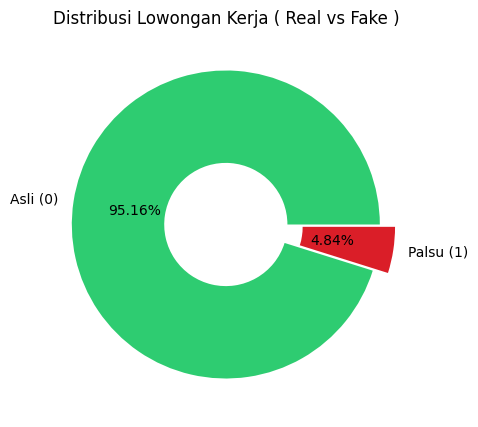

In [50]:
# Menghitung frekuensi kelas target beserta presntasinya
target_distribution = pd.DataFrame({
    "Jumlah": df["fraudulent"].value_counts(),
    "Persentase (%)": (df["fraudulent"].value_counts(normalize=True) * 100).round(2)
})

# setting palet untuk kategori asli dan palsu
target_distribution.index = ["Asli (0)", "Palsu (1)"]
warna = ['#2ecc71', '#DA1E28']

# Visaulisasi pakai donut chart
target_distribution["Jumlah"].plot.pie(
    figsize=(5, 5),
    colors=warna,
    autopct='%1.2f%%',
    explode=(0, 0.1), # menjorokkan ke luar potongan target yang palsu
    wedgeprops=dict(width=0.6),
    ylabel='',
    title="Distribusi Lowongan Kerja ( Real vs Fake )"
)

Tujuan dari langkah ini adalah untuk melihat perbandingan jumlah lowongan kerja asli dengan lowongan kerja palsu di dalam dataset.

Berdasarkan hasil output di atas, kami menemukan ketidakseimbangan kelas target (*class imbalance*) yang sangat jomplang
- Lowongan Kerja Asli (Real): 17.014 data (95,16%)
- Lowongan Kerja Palsu (Fraudulent): 866 data (4,84%)

Temuan ini sangat penting karena menunjukkan rasio ketimpangan data yang mencapai hampir 20 kali lipat. Jika kami langsung melatih model pada sebaran data ini, model akan cenderung malas belajar dan selalu menebak Asli agar akurasinya terlihat tinggi. Oleh karena itu, ketidakseimbangan ini harus kami tangani dengan teknik penyeimbangan kelas (*class balancing*) pada data latih nanti.

**2.9 Analisis Fitur Biner**

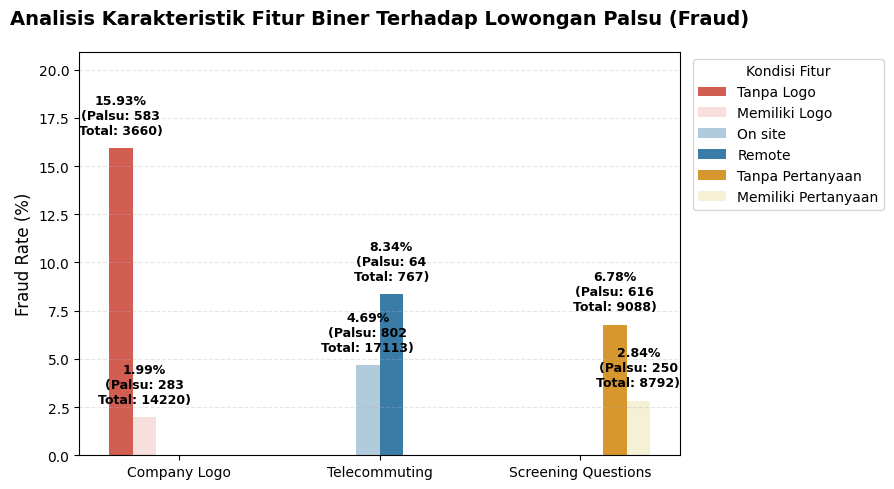

In [51]:
# Cek fitur biner yang sudah dikategorikan sebelumnya yaitu has compay logo, telecommuting dan has questions
# fungsi  menghitung presentase lowongan palsu
def fraud_rate_by_feature(data, feature):
    result = (
        data.groupby(feature)["fraudulent"]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )
    result["Fraud Rate (%)"] = (result["mean"] * 100).round(2)
    result = result.rename(columns={"count": "Total", "sum": "Jumlah Palsu"})
    return result.sort_values("Fraud Rate (%)", ascending=False)

# Ambil 3 fitur binner tadi untuk di cek
rate_logo = fraud_rate_by_feature(df, "has_company_logo")
rate_remote = fraud_rate_by_feature(df, "telecommuting")
rate_questions = fraud_rate_by_feature(df, "has_questions")

data_grafik = pd.DataFrame({
    "Fitur Biner": [
        "Tanpa Logo", "Memiliki Logo",
        "On site", "Remote",
        "Tanpa Pertanyaan", "Memiliki Pertanyaan"
    ],
    "Fraud Rate (%)": [
        rate_logo.loc[rate_logo["has_company_logo"] == 0, "Fraud Rate (%)"].values[0],
        rate_logo.loc[rate_logo["has_company_logo"] == 1, "Fraud Rate (%)"].values[0],
        rate_remote.loc[rate_remote["telecommuting"] == 0, "Fraud Rate (%)"].values[0],
        rate_remote.loc[rate_remote["telecommuting"] == 1, "Fraud Rate (%)"].values[0],
        rate_questions.loc[rate_questions["has_questions"] == 0, "Fraud Rate (%)"].values[0],
        rate_questions.loc[rate_questions["has_questions"] == 1, "Fraud Rate (%)"].values[0],
    ],
    "Detail Angka": [
        f"Palsu: {rate_logo.loc[rate_logo['has_company_logo'] == 0, 'Jumlah Palsu'].values[0]}\nTotal: {rate_logo.loc[rate_logo['has_company_logo'] == 0, 'Total'].values[0]}",
        f"Palsu: {rate_logo.loc[rate_logo['has_company_logo'] == 1, 'Jumlah Palsu'].values[0]}\nTotal: {rate_logo.loc[rate_logo['has_company_logo'] == 1, 'Total'].values[0]}",
        f"Palsu: {rate_remote.loc[rate_remote['telecommuting'] == 0, 'Jumlah Palsu'].values[0]}\nTotal: {rate_remote.loc[rate_remote['telecommuting'] == 0, 'Total'].values[0]}",
        f"Palsu: {rate_remote.loc[rate_remote['telecommuting'] == 1, 'Jumlah Palsu'].values[0]}\nTotal: {rate_remote.loc[rate_remote['telecommuting'] == 1, 'Total'].values[0]}",
        f"Palsu: {rate_questions.loc[rate_questions['has_questions'] == 0, 'Jumlah Palsu'].values[0]}\nTotal: {rate_questions.loc[rate_questions['has_questions'] == 0, 'Total'].values[0]}",
        f"Palsu: {rate_questions.loc[rate_questions['has_questions'] == 1, 'Jumlah Palsu'].values[0]}\nTotal: {rate_questions.loc[rate_questions['has_questions'] == 1, 'Total'].values[0]}",
    ],
    "Kategori": [
        "Company Logo", "Company Logo",
        "Telecommuting", "Telecommuting",
        "Screening Questions", "Screening Questions"
    ]
})

# color palete spesifik untuk tiap fitur biner
warna = {
    "Tanpa Logo": "#e74c3c",
    "Memiliki Logo": "#fadbd8",
    "On site": "#a9cce3",
    "Remote": "#2980b9",
    "Tanpa Pertanyaan": "#f39c12",
    "Memiliki Pertanyaan": "#fcf3cf"
}

# render grafik batang kelompok
plt.figure(figsize=(9, 5))
grafik = sns.barplot(
    data=data_grafik,
    x="Kategori",
    y="Fraud Rate (%)",
    hue="Fitur Biner",
    palette=warna,
    width=0.7
)

# Menampilkan persentase dan jumlah detail
label_texts = data_grafik["Detail Angka"].tolist()
idx = 0
for container in grafik.containers:
    labels = []
    for bar in container:
        h = bar.get_height()
        if pd.notnull(h) and h > 0:
            labels.append(f"{h:.2f}%\n({label_texts[idx]})")
            idx += 1
        else:
            labels.append("")
    grafik.bar_label(container, labels=labels, padding=8, fontweight='bold', fontsize=9)

plt.title("Analisis Karakteristik Fitur Biner Terhadap Lowongan Palsu (Fraud)", fontweight='bold', fontsize=14, pad=20)
plt.ylabel("Fraud Rate (%)", fontsize=12)
plt.xlabel("", fontsize=12)
plt.ylim(0, data_grafik["Fraud Rate (%)"].max() + 5)
plt.legend(title="Kondisi Fitur", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Analisis Temuan Fitur Biner :

1. Company Logo
Lowongan kerja tanpa logo memiliki tingkat penipuan sebesar 15.93% (583 kasus dari 3.660 data). Angka ini jauh lebih tinggi dibandingkan lowongan yang mencantumkan logo resmi, yaitu hanya sebesar 1.99% (283 kasus dari 14.220 data).

2. Telecommuting
Lowongan kerja dengan opsi remote memiliki tingkat penipuan sebesar 8.34% (64 kasus dari 767 data). Persentase ini lebih tinggi dibandingkan lowongan kerja fisik atau on-site yang hanya sebesar 4.69% (802 kasus dari 17.113 data).

3. Screening Questions
Lowongan kerja tanpa pertanyaan penyaringan memiliki tingkat penipuan sebesar 6.78% (616 kasus dari 9.088 data), sedangkan lowongan yang menyertakan pertanyaan penyaringan memiliki tingkat penipuan lebih rendah yaitu sebesar 2.84% (250 kasus dari 8.792 data).

Jadi ketiadaan logo perusahaan dan tidak adanya pertanyaan penyaringan merupakan dua ciri khas yang paling sering ditemui pada kasus lowongan kerja palsu. Temuan ini menjadi informasi pembeda yang sangat berguna bagi model klasifikasi kami.

**2.10 Analisi Fitur kategorikal**

In [52]:
# Fungsi menghitung jumlah data, jumlah lowongan fake, dan persentase fake pada setiap kategori
def fraud_rate_by_feature(data, feature):

    # Menghitung statistik berdasarkan kategori
    result = (
        data.groupby(feature)["fraudulent"]
        .agg(
            total_data="count",
            jumlah_fake="sum",
            fake_rate="mean"
        )
        .sort_values("fake_rate", ascending=False)
        .reset_index()
    )

    styled_result = (
        result.style
        # Tampilkan fake_rate dalam format persen
        .format({
            "fake_rate": "{:.2%}"
        })
        # Gradasi warna berdasarkan nilai fake_rate
        .background_gradient(
            subset=["fake_rate"],
            cmap="YlOrBr"
        )
    )

    return styled_result

Fungsi fraud_rate_by_feature di atas kami gunakan untuk membuat visualisasi berupa tabel heatmap (gradasi warna).

Melalui tabel interaktif ini, kami dapat menganalisis tingkat kerawanan penipuan pada setiap kategori di dalam data loker. Warna gradasi dari kuning hingga cokelat yang semakin gelap menunjukkan persentase lowongan palsu yang semakin tinggi. Visualisasi tabel ini memudahkan kami dalam mendeteksi kategori mana saja yang paling rawan disalahgunakan oleh penipu loker bodong.

**2.10.1 Analisis fake rate berdasarkan tipe pekerjaan**

In [53]:
# dataframe disalin dan kami isi data kosong untuk analisis tipe pekerjaan
df_employment = df.copy()
df_employment["employment_type"] = df_employment["employment_type"].fillna("Tidak Diketahui")

employment_analysis = fraud_rate_by_feature(df_employment, "employment_type")
employment_analysis

,employment_type,total_data,jumlah_fake,fake_rate
0,Part-time,797,74,9.28%
1,Tidak Diketahui,3471,241,6.94%
2,Other,227,15,6.61%
3,Full-time,11620,490,4.22%
4,Contract,1524,44,2.89%
5,Temporary,241,2,0.83%


Melalui tabel di atas, kami dapat mengidentifikasi kategori pekerjaan mana saja yang paling rawan terhadap kasus penipuan loker
1. Part-time memiliki persentase penipuan tertinggi yaitu sebesar 9.28% (74 lowongan palsu dari 797 data).
2. Tidak Diketahui (kolom kosong) berada di posisi kedua dengan tingkat penipuan sebesar 6.94% (241 lowongan palsu dari 3.471 data).
3. Other (tipe lainnya) memiliki persentase penipuan sebesar 6.61% (15 lowongan palsu dari 227 data).
4. Full-time memiliki persentase penipuan sebesar 4.22% (490 lowongan palsu dari 11.620 data). Meskipun persentasenya di bawah tipe paruh waktu, tipe ini menyumbang jumlah kasus palsu terbanyak secara nominal karena datanya yang sangat besar.
5. Contract dan Temporary memiliki tingkat penipuan terendah, masing-masing hanya sebesar 2.89% (44 lowongan palsu) dan 0.83% (2 lowongan palsu).

Hasil ini memberikan informasi tambahan bagi model kami untuk membedakan tingkat risiko penipuan dari masing-masing tipe pekerjaan.

**2.10.2 Analisis fake rate berdasatrkan pengalaman kerja**

In [54]:
fraud_rate_by_feature(
    df.fillna({"required_experience": "Tidak Diketahui"}),
    "required_experience"
)

,required_experience,total_data,jumlah_fake,fake_rate
0,Executive,141,10,7.09%
1,Entry level,2697,179,6.64%
2,Tidak Diketahui,7050,435,6.17%
3,Not Applicable,1116,60,5.38%
4,Director,389,17,4.37%
5,Mid-Senior level,3809,113,2.97%
6,Internship,381,10,2.62%
7,Associate,2297,42,1.83%


kami menemukan beberapa poin penting terkait tingkat penipuan loker berdasarkan pengalaman kerja 
1. Kategori Executive memiliki persentase penipuan tertinggi sebesar 7.09% (10 lowongan palsu dari 141 data).
2. Kategori Entry level  berada di posisi kedua dengan persentase penipuan sebesar 6.64% (179 lowongan palsu dari 2.697 data).
3. Kategori Tidak Diketahui memiliki tingkat penipuan sebesar 6.17% (435 lowongan palsu dari 7.050 data). Kolom kosong ini menyumbang jumlah kasus palsu terbanyak secara nominal karena jumlah datanya yang besar.
4. Kategori Director memiliki tingkat penipuan sebesar 4.37% (17 lowongan palsu dari 389 data).
5. Kategori Mid-Senior level, Internship, dan Associate memiliki tingkat kerawanan penipuan terkecil, berkisar antara 1.83% hingga 2.97%.

maka hal ini menunjukkan bahwa pelaku penipuan cenderung menyasar pencari kerja tingkat pemula atau memilih untuk menyembunyikan syarat pengalaman kerja (Tidak Diketahui).

**2.10.3 Analisis fake rate berdasarkan pendidikan**

In [55]:
fraud_rate_by_feature(
    df.fillna({"required_education": "Tidak Diketahui"}),
    "required_education"
)

,required_education,total_data,jumlah_fake,fake_rate
0,Some High School Coursework,27,20,74.07%
1,Certification,170,19,11.18%
2,High School or equivalent,2080,170,8.17%
3,Master's Degree,416,31,7.45%
4,Tidak Diketahui,8105,451,5.56%
5,Professional,74,4,5.41%
6,Unspecified,1397,61,4.37%
7,Doctorate,26,1,3.85%
8,Some College Coursework Completed,102,3,2.94%
9,Associate Degree,274,6,2.19%


Dari visualisasi tabel di atas, kami memperoleh temuan mengenai persentase penipuan loker berdasarkan syarat pendidikan
1. Kategori Some High School Coursework atau belum lulus SMA memiliki persentase penipuan tertinggi yaitu sebesar 74.07% (20 lowongan palsu dari 27 data).
2. Kategori Certification (sertifikasi) berada di posisi kedua dengan tingkat penipuan sebesar 11.18% (19 lowongan palsu dari 170 data).
3. Kategori High School or equivalent (SMA atau sederajat) memiliki tingkat penipuan sebesar 8.17% (170 lowongan palsu dari 2.080 data).
4. Kategori Tidak Diketahui memiliki tingkat penipuan sebesar 5.56% (451 lowongan palsu dari 8.105 data). Kolom kosong ini menyumbang jumlah kasus palsu terbanyak secara nominal.
5. Kategori Bachelor's Degree (S1 / Sarjana) memiliki tingkat penipuan yang sangat rendah yaitu hanya sebesar 1.94% (100 lowongan palsu dari 5.145 data), menjadikannya kategori syarat pendidikan yang paling aman.

Ini mengindikasikan bahwa lowongan palsu lebih sering menargetkan pelamar dengan kualifikasi pendidikan menengah ke bawah seperti SMA dibandingkan dengan pelamar yang mensyaratkan gelar Sarjana.

**2.10.4 Analisis dake rate berdaasarkan industri**

In [56]:
# Menghitung jumlah industri unik
df["industry"].nunique()

131

Bagian kode ini fungsinya untuk mengecek total kategori industri yang berbeda pada kolom industry. Kami menggunakan fungsi nunique() supaya cuma nilai uniknya saja yang dihitung, alias data yang sama persis tidak akan terhitung ganda

In [57]:
# Hitung statistik lowongan pada setiap industri
industry_analysis = (
    df
    .groupby("industry")["fraudulent"]
    .agg(
        total_data="count",
        jumlah_fake="sum",
        fake_rate="mean"
    )
)

# Ubah fake rate menjadi persentase
industry_analysis["fake_rate"] = (
    industry_analysis["fake_rate"] * 100
).round(2)

# Urutkan berdasarkan fake rate tertinggi
industry_analysis.sort_values(
    "fake_rate",
    ascending=False
).head(10)

,total_data,jumlah_fake,fake_rate
industry,,,
Ranching,1,1,100.00
Military,2,1,50.00
Animation,5,2,40.00
Oil & Energy,287,109,37.98
Accounting,159,57,35.85
"Leisure, Travel & Tourism",76,21,27.63
Computer Networking,44,12,27.27
Executive Office,8,2,25.00
Defense & Space,9,2,22.22


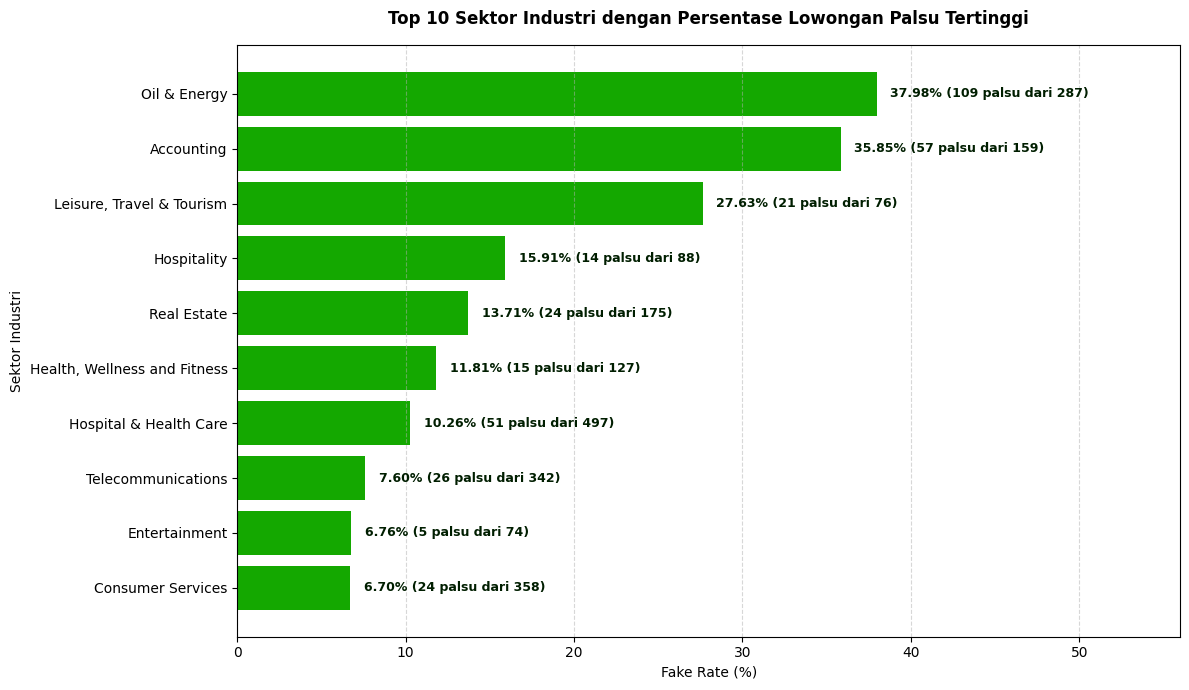

In [58]:
# minimum jumlah data per industri
MIN_SAMPLE = 50

# Filter industri yang memiliki minimal 50 data
industry_reliable = industry_analysis[industry_analysis["total_data"] >= MIN_SAMPLE]
top_10_industry = industry_reliable.sort_values("fake_rate", ascending=False).head(10)

top_10_sorted = top_10_industry.sort_values("fake_rate", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

# grafik batang horizontal
bars = ax.barh(
    top_10_sorted.index, 
    top_10_sorted["fake_rate"], 
    color="#14a800" 
)

for bar, (idx, row) in zip(bars, top_10_sorted.iterrows()):
    width = bar.get_width() 
    jumlah_fake = row["jumlah_fake"]
    total_data = row["total_data"]
    label_text = f"{width:.2f}% ({int(jumlah_fake)} palsu dari {int(total_data)})"
    ax.text(
        width + 0.8, 
        bar.get_y() + bar.get_height() / 2, 
        label_text, 
        va="center", 
        ha="left", 
        fontsize=9, 
        color="#001e00",
        fontweight="bold"
    )

ax.set_title("Top 10 Sektor Industri dengan Persentase Lowongan Palsu Tertinggi", fontsize=12, fontweight="bold", pad=15)
ax.set_xlabel("Fake Rate (%)", fontsize=10)
ax.set_ylabel("Sektor Industri", fontsize=10)
ax.set_xlim(0, max(top_10_sorted["fake_rate"]) + 18) 
ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Agar hasil analisis ini lebih valid dan mewakili kondisi lapangan, kami menyaring data hanya pada sektor industri yang memiliki minimal 50 iklan lowongan kerja di dalam dataset.

Berdasarkan hasil tersebut, kami menemukan lima besar industri dengan persentase penipuan loker tertinggi
1. Kategori Oil & Energy memiliki tingkat penipuan tertinggi yaitu sebesar 37.98% (109 lowongan palsu dari 287 data).
2. Kategori Accounting menempati urutan kedua dengan persentase penipuan sebesar 35.85% (57 lowongan palsu dari 159 data).
3. Kategori Leisure, Travel & Tourism memiliki persentase penipuan sebesar 27.63% (21 lowongan palsu dari 76 data).
4. Kategori Hospitality memiliki persentase penipuan sebesar 15.91% (14 lowongan palsu dari 88 data).
5. Kategori Real Estate memiliki persentase penipuan sebesar 13.71% (24 lowongan palsu dari 175 data).

Informasi yang diperoleh bahwa pelaku penipuan sangat sering memanfaatkan nama besar sektor industri energi seperti minyak dan gas serta keuangan seperti akuntansi

**2.10.5 Analisis fake rate berdasarkan function**

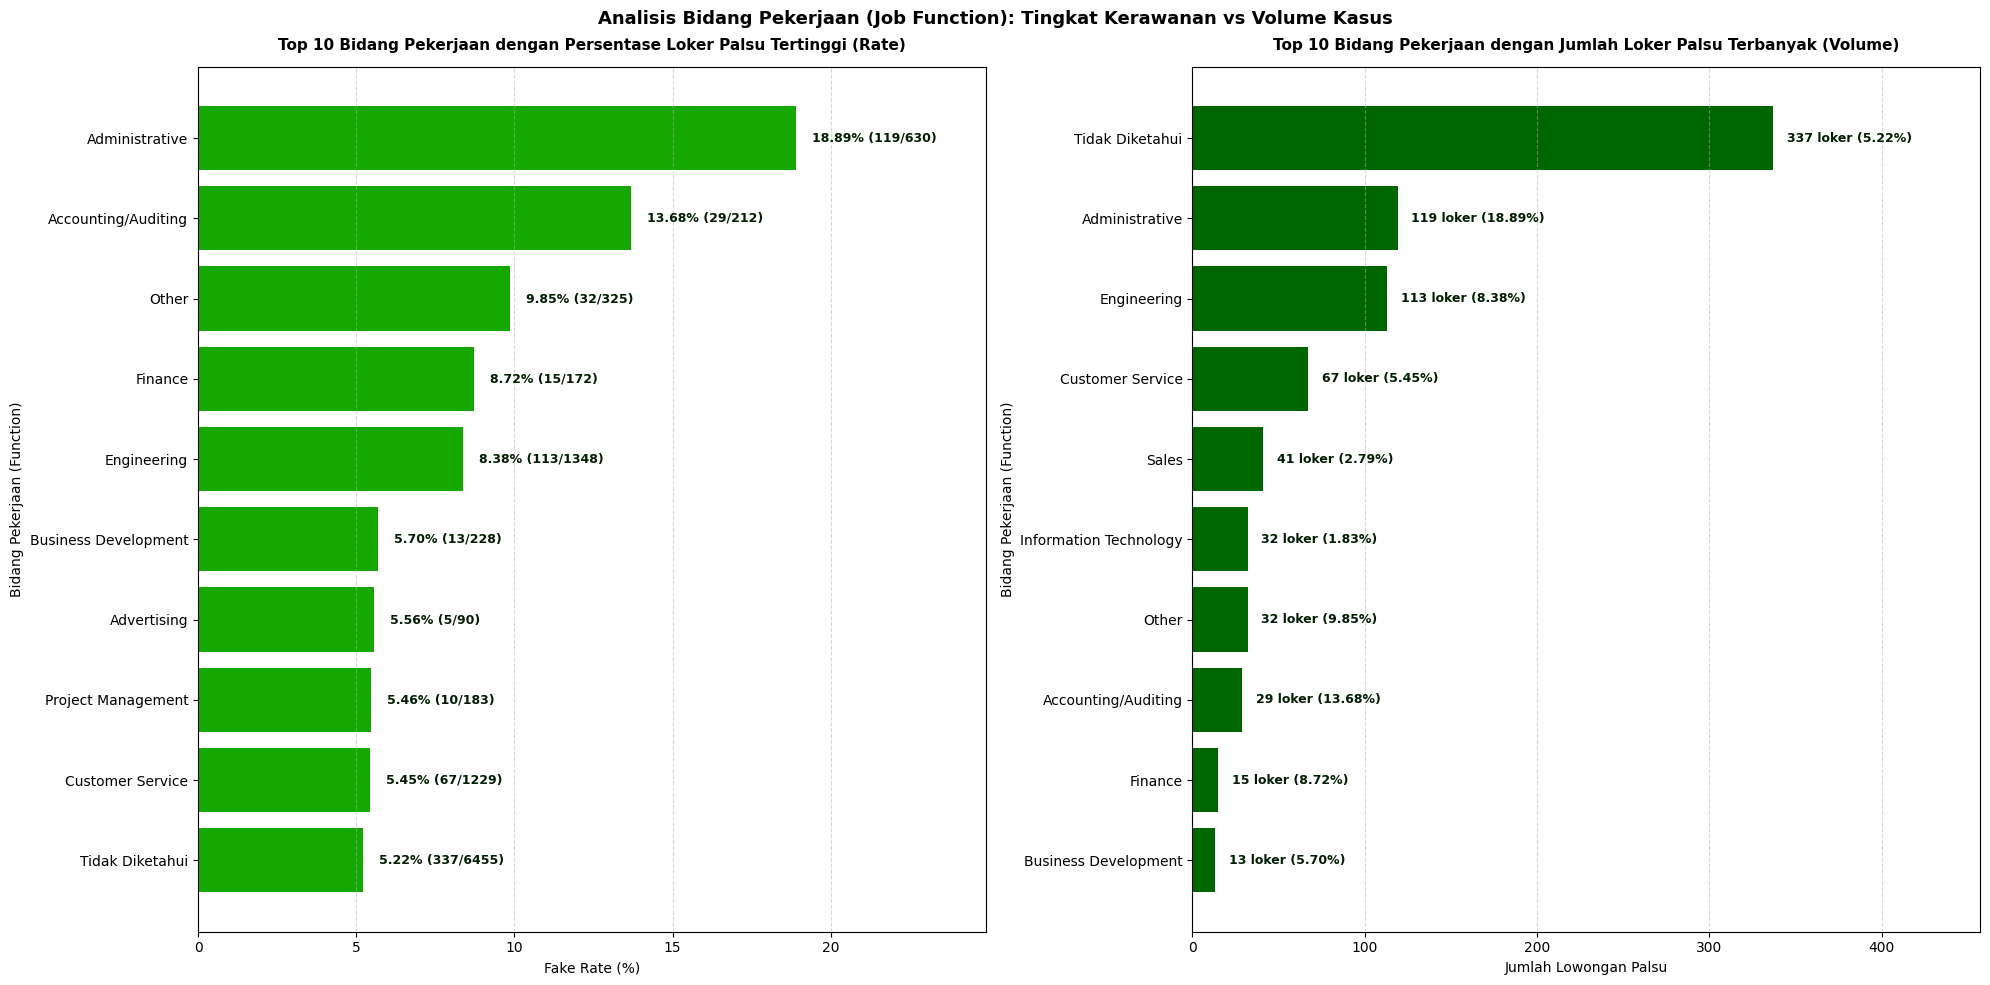

In [59]:
df_function = df.copy()

# Mengisi missing value dengan kategori "Tidak Diketahui"
df_function["function"] = df_function["function"].fillna("Tidak Diketahui")

# Statistik setiap kategori function
function_analysis = (
    df_function
    .groupby("function")["fraudulent"]
    .agg(
        total_data="count",
        jumlah_fake="sum",
        fake_rate="mean"
    )
)

function_analysis["fake_rate"] = (
    function_analysis["fake_rate"] * 100
).round(2)

# Filter kategori yang memiliki minimal 50 data untuk menjaga validitas statistik
MIN_SAMPLE = 50
function_reliable = function_analysis[function_analysis["total_data"] >= MIN_SAMPLE]

# Top 10 berdasarkan Fake Rate 
top_10_rate = function_reliable.sort_values("fake_rate", ascending=False).head(10)
top_10_rate_sorted = top_10_rate.sort_values("fake_rate", ascending=True)

# Top 10 berdasarkan Jumlah Loker Palsu (Volume)
top_10_volume = function_reliable.sort_values("jumlah_fake", ascending=False).head(10)
top_10_volume_sorted = top_10_volume.sort_values("jumlah_fake", ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Persentase Kerawanan (Fake Rate)
bars1 = ax1.barh(
    top_10_rate_sorted.index, 
    top_10_rate_sorted["fake_rate"], 
    color="#14a800" 
)
for bar, (idx, row) in zip(bars1, top_10_rate_sorted.iterrows()):
    width = bar.get_width()
    jumlah_fake = row["jumlah_fake"]
    total_data = row["total_data"]
    label_text = f"{width:.2f}% ({int(jumlah_fake)}/{int(total_data)})"
    ax1.text(
        width + 0.5, 
        bar.get_y() + bar.get_height() / 2, 
        label_text, 
        va="center", 
        ha="left", 
        fontsize=9, 
        color="#001e00",
        fontweight="bold"
    )
ax1.set_title("Top 10 Bidang Pekerjaan dengan Persentase Loker Palsu Tertinggi (Rate)", fontsize=11, fontweight="bold", pad=12)
ax1.set_xlabel("Fake Rate (%)", fontsize=10)
ax1.set_ylabel("Bidang Pekerjaan (Function)", fontsize=10)
ax1.set_xlim(0, max(top_10_rate_sorted["fake_rate"]) + 6)
ax1.grid(axis="x", linestyle="--", alpha=0.5)

# Jumlah Kasus Penipuan (Volume)
bars2 = ax2.barh(
    top_10_volume_sorted.index, 
    top_10_volume_sorted["jumlah_fake"], 
    color="#006600" 
)
for bar, (idx, row) in zip(bars2, top_10_volume_sorted.iterrows()):
    width = bar.get_width() 
    fake_rate = row["fake_rate"]
    total_data = row["total_data"]
    label_text = f"{int(width)} loker ({fake_rate:.2f}%)"
    ax2.text(
        width + 8, 
        bar.get_y() + bar.get_height() / 2, 
        label_text, 
        va="center", 
        ha="left", 
        fontsize=9, 
        color="#001e00",
        fontweight="bold"
    )
ax2.set_title("Top 10 Bidang Pekerjaan dengan Jumlah Loker Palsu Terbanyak (Volume)", fontsize=11, fontweight="bold", pad=12)
ax2.set_xlabel("Jumlah Lowongan Palsu", fontsize=10)
ax2.set_ylabel("Bidang Pekerjaan (Function)", fontsize=10)
ax2.set_xlim(0, max(top_10_volume_sorted["jumlah_fake"]) + 120) 
ax2.grid(axis="x", linestyle="--", alpha=0.5)

plt.suptitle("Analisis Bidang Pekerjaan (Job Function): Tingkat Kerawanan vs Volume Kasus", fontsize=13, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

Berdasarkan hasil visualisasi grafik di atas, kami menemukan dua sudut pandang

1. Tingkat Kerawanan Tertinggi (Fake Rate)
- Bidang Administrative memiliki persentase penipuan tertinggi yaitu sebesar 18.89% (119 lowongan palsu dari 630 data).
- Bidang Accounting/Auditing berada di posisi kedua dengan persentase penipuan sebesar 13.68% (29 lowongan palsu dari 212 data).
- Diikuti berturut-turut oleh Other (9.85%), Finance (8.72%), dan Engineering (8.38%).

2. Jumlah Kasus Terbanyak secara Nominal
- Kategori Tidak Diketahui memiliki persentase penipuan yang relatif kecil (5.22%) sehingga ukuran batangnya di grafik terlihat paling kecil di antara 10 besar. Namun secara nominal, kategori ini justru menyumbang jumlah penipuan terbanyak secara mutlak yaitu sebesar 337 lowongan palsu. Hal ini disebabkan karena jumlah total lowongan yang tidak mencantumkan bidang pekerjaan sangatlah besar (6.455 data).
- Posisi kedua disusul oleh Administrative (119 lowongan palsu) dan Engineering (113 lowongan palsu).

Temuan ini sangat penting karena menunjukkan bahwa penipu sering kali membiarkan informasi bidang pekerjaan kosong , atau jika mereka mengisinya, mereka cenderung memilih bidang administrasi atau teknik untuk memikat korban.

**2.11 Analisis kelengkapan Informasi**

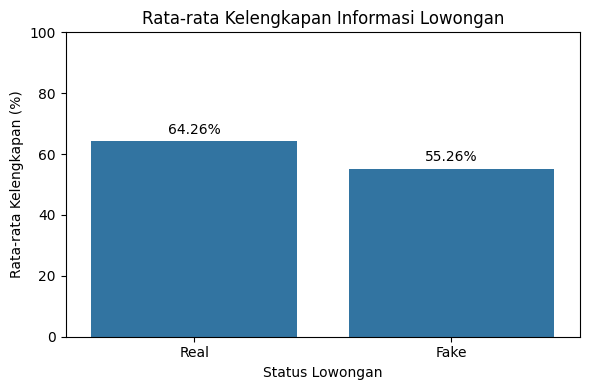

In [60]:
# Kolom informasi yang digunakan untuk mengukur kelengkapan lowongan
info_columns = [
    "company_profile",
    "salary_range",
    "requirements",
    "benefits",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

# Salin dataframe
temp_df = df.copy()

# Hitung persentase kelengkapan informasi setiap lowongan
temp_df["completeness_score"] = (
    temp_df[info_columns]
    .notna()
    .mean(axis=1) * 100
)

# Statistik kelengkapan berdasarkan status lowongan
temp_df.groupby("fraudulent")["completeness_score"].describe()

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=temp_df,
    x="fraudulent",
    y="completeness_score",
    errorbar=None
)

# Ubah label kategori
ax.set_xticks([0, 1])
ax.set_xticklabels(["Real", "Fake"])

# persentase di atas batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.title("Rata-rata Kelengkapan Informasi Lowongan")
plt.xlabel("Status Lowongan")
plt.ylabel("Rata-rata Kelengkapan (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

Melalui perhitungan skor kelengkapan data (completeness score) dari sembilan kolom krusial di atas, kami menemukan pola perbedaan yang jelas antara lowongan kerja asli dan lowongan kerja palsu:
1. Lowongan asli memiliki rata-rata kelengkapan informasi sebesar 64.26% dengan nilai median mencapai 77.78%. Hal ini menandakan bahwa mayoritas perusahaan yang sah cenderung mengisi data lowongan secara mendalam (lebih dari tiga perempat informasi terisi).
2. Lowongan palsu memiliki rata-rata kelengkapan informasi yang lebih rendah yaitu sebesar 55.26% dengan nilai median sebesar 55.56%. Rata-rata iklan lowongan palsu hanya terisi sekitar separuhnya saja.

Temuan ini membuktikan secara nyata bahwa pembuat lowongan palsu cenderung membiarkan banyak kolom informasi kosong (seperti salary_range, benefits, atau company_profile). Perbedaan tingkat kelengkapan ini akan kami gunakan sebagai salah satu fitur penting dalam proses pemodelan klasifikasi.

**2.12 Mengeksplorasi Data Kategori TEKS**

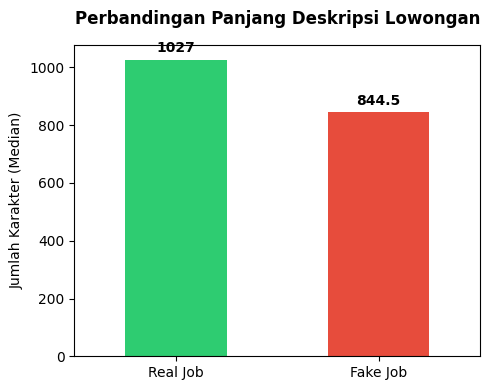

In [61]:
temp_df = df.copy()
temp_df['panjang_deskripsi'] = temp_df['description'].fillna("").str.len()

tabel_median = temp_df.groupby("fraudulent")["panjang_deskripsi"].median()

tabel_median.index = ["Real Job", "Fake Job"]

# grafik batang
ax = tabel_median.plot(
    kind='bar',
    color=['#2ecc71', '#e74c3c'], # Hijau untuk Asli, Merah untuk Palsu
    figsize=(5, 4),
    rot=0
)

ax.bar_label(ax.containers[0], padding=3, fontweight='bold')

plt.title("Perbandingan Panjang Deskripsi Lowongan", fontweight='bold', pad=15)
plt.ylabel("Jumlah Karakter (Median)")
plt.xlabel("")

# Tampilkan grafik
plt.tight_layout()
plt.show()

Melalui perbandingan panjang teks deskripsi lowongan kerja asli dan palsu, kami menemukan perbedaan yaitu
1. Lowongan asli memiliki nilai median panjang deskripsi sebesar 1.027 karakter. Hal ini menunjukkan bahwa lowongan asli cenderung memberikan rincian pekerjaan yang lebih komprehensif dan mendalam.
2. Lowongan palsu memiliki nilai median panjang deskripsi yang lebih pendek yaitu sebesar 845 karakter.

informasi yang didapat bahwa pelaku penipuan cenderung menulis deskripsi pekerjaan yang lebih singkat dan kurang detail. Perbedaan panjang teks ini akan sangat membantu model klasifikasi kami sebagai salah satu indikator pendukung.

In [62]:
summary = pd.DataFrame({
    "Jumlah Data": df.groupby("fraudulent").size(),

    "Persentase Memiliki Logo":
        df.groupby("fraudulent")[
            "has_company_logo"
        ].mean() * 100,

    "Persentase Memiliki Pertanyaan":
        df.groupby("fraudulent")[
            "has_questions"
        ].mean() * 100,

    "Persentase Telecommuting":
        df.groupby("fraudulent")[
            "telecommuting"
        ].mean() * 100
})

summary.index = [
    "Real Job",
    "Fake Job"
]

summary.round(2)

,Jumlah Data,Persentase Memiliki Logo,Persentase Memiliki Pertanyaan,Persentase Telecommuting
Real Job,17014,81.91,50.21,4.13
Fake Job,866,32.68,28.87,7.39


Melalui tabel ringkasan di atas, kami dapat membandingkan perbedaan yang sangat kontras pada karakteristik utama lowongan kerja asli dan palsu:
1. Sebanyak 81.91% lowongan asli mencantumkan logo perusahaan resmi, sedangkan pada lowongan palsu angka ini menurun drastis menjadi hanya 32.68%.
2. Sebanyak 50.21% lowongan asli menyertakan pertanyaan seleksi awal, sementara pada lowongan palsu persentasenya hanya sebesar 28.87%.
3. Lowongan asli yang menawarkan kerja remote hanya sebesar 4.13%. Sebaliknya pada lowongan palsu, penawaran kerja remote justru lebih tinggi yaitu sebesar 7.39%.

hal ini membuktikan secara jelas bahwa lowongan palsu cenderung tidak memiliki logo resmi perusahaan, jarang menyertakan pertanyaan penyaringan, namun sering kali mengiming-imingi pelamar dengan sistem kerja remote (WFH) untuk menarik perhatian korban.

# **3. Data Preparation**

Pada tahap Data Preparation ini, kami menyiapkan data mentah agar siap diproses oleh algoritma machine learning. Proses penyiapan data ini kami lakukan secara terarah berdasarkan temuan penting atau insight dari tahap Data Understanding sebelumnya

1. Kelengkapan Informasi & Panjang Teks
- Lowongan palsu cenderung lebih kosong (rata-rata kelengkapan 55.26% vs 64.26%) dan memiliki deskripsi teks yang lebih pendek.
- Kami melakukan Feature Engineering untuk mengekstrak fitur baru berupa indikator keberadaan (has_company_profile, has_requirements, dll.), panjang karakter teks (description_length, company_profile_length, dll.), serta skor kelengkapan isi (completeness_score, missing_count).

2. Karakteristik Biner (Logo & Pertanyaan)
- Ketiadaan logo perusahaan dan tidak adanya pertanyaan penyaringan adalah ciri kuat loker palsu.
- Kami mempertahankan kolom has_company_logo dan has_questions sebagai fitur biner masukan model.

3. Redundansi Kolom Teks & Kategori Kompleks
- Kolom seperti location memiliki alamat yang terlalu detail, sedangkan kolom teks panjang (seperti company_profile dan description) tidak bisa dibaca langsung oleh model non-NLP.
- Kami menyederhanakan kolom location dengan hanya mengambil kode negaranya saja (country). Kolom teks mentah yang tidak digunakan akan kami hapus, dan data kosong pada kolom kategorikal lainnya akan diisi dengan label "Tidak Diketahui" sebelum diproses dengan One-Hot Encoder.


**3.1 Pembuatan fitur baru / feature engineering**

In [63]:
df_prepared = df.copy()

# Ekstraksi kode negara dari lokasi ( formatnya 'US, NY, New York' -> diambil 'US')
df_prepared['country'] = df['location'].apply(lambda x: str(x).split(',')[0].strip() if pd.notnull(x) else 'Unspecified')

# Binerisasi kolom teks (1 jika ada, 0 jika kosong)
df_prepared['has_company_profile'] = df['company_profile'].apply(lambda x: 1 if pd.notnull(x) else 0)
df_prepared['has_requirements'] = df['requirements'].apply(lambda x: 1 if pd.notnull(x) else 0)
df_prepared['has_benefits'] = df['benefits'].apply(lambda x: 1 if pd.notnull(x) else 0)
df_prepared['has_salary_range'] = df['salary_range'].notna().astype(int)
df_prepared['has_department'] = df['department'].notna().astype(int)

# Mengukur panjang karakter teks
df_prepared['description_length'] = df['description'].apply(lambda x: len(str(x)) if pd.notnull(x) else 0)
df_prepared['requirements_length'] = df['requirements'].apply(lambda x: len(str(x)) if pd.notnull(x) else 0)
df_prepared['benefits_length'] = df['benefits'].apply(lambda x: len(str(x)) if pd.notnull(x) else 0)
df_prepared['company_profile_length'] = df['company_profile'].apply(lambda x: len(str(x)) if pd.notnull(x) else 0)
df_prepared['title_length'] = df['title'].fillna('').str.len()

# Mengukur skor kelengkapan postingan lowongan
info_columns = ['company_profile', 'salary_range', 'requirements', 'benefits', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
df_prepared['completeness_score'] = df[info_columns].notna().mean(axis=1)
df_prepared['missing_count'] = df[info_columns].isna().sum(axis=1)

print('Fitur baru berhasil ditambahkan!')
df_prepared[['title_length', 'completeness_score', 'missing_count', 'has_salary_range', 'has_department']].head()


Fitur baru berhasil ditambahkan!


,title_length,completeness_score,missing_count,has_salary_range,has_department
0,16,0.555556,4,0,1
1,41,0.777778,2,0,1
2,39,0.222222,7,0,0
3,33,0.888889,1,0,1
4,19,0.888889,1,0,0


Fitur baru yang kami buat di atas membantu model untuk mempelajari pola kelengkapan dari pembuat lowongan kerja. Secara umum, lowongan kerja asli dari perusahaan yang sah cenderung memiliki informasi yang lebih lengkap (seperti profil perusahaan, rentang gaji, dan departemen) dibandingkan lowongan palsu yang sering dibiarkan kosong.

**3.2 Pembersihan Kolom Mentah dan Pengisian Data Kosong kategorikal**

In [64]:
cols_to_drop = ['job_id', 'title', 'location', 'salary_range', 'department', 'company_profile', 'description', 'requirements', 'benefits']
df_prepared = df_prepared.drop(columns=cols_to_drop, errors='ignore')

# Isi missing value pada kolom kategorikal sisa dengan 'Unspecified'
categorical_cols = ['country', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
df_prepared[categorical_cols] = df_prepared[categorical_cols].fillna('Unspecified')

print('Sisa missing value di dataset:')
print(df_prepared.isnull().sum())


Sisa missing value di dataset:
telecommuting             0
has_company_logo          0
has_questions             0
employment_type           0
required_experience       0
required_education        0
industry                  0
function                  0
fraudulent                0
country                   0
has_company_profile       0
has_requirements          0
has_benefits              0
has_salary_range          0
has_department            0
description_length        0
requirements_length       0
benefits_length           0
company_profile_length    0
title_length              0
completeness_score        0
missing_count             0
dtype: int64


**3.3 Train Test Split**

In [65]:
from sklearn.model_selection import train_test_split

X = df_prepared.drop(columns=['fraudulent'])
y = df_prepared['fraudulent']

# Split data 80% train, 20% test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Jumlah data latihan (X_train): {X_train.shape[0]} baris')
print(f'Jumlah data uji (X_test): {X_test.shape[0]} baris')
print('\nDistribusi kelas target pada data uji (merepresentasikan dunia nyata):')
print(y_test.value_counts(normalize=True) * 100)


Jumlah data latihan (X_train): 14304 baris
Jumlah data uji (X_test): 3576 baris

Distribusi kelas target pada data uji (merepresentasikan dunia nyata):
fraudulent
0    95.162192
1     4.837808
Name: proportion, dtype: float64


Dengan memisahkan data uji (train-test split) di awal sebelum melakukan penyeimbangan kelas pada data latih, data uji kami tetap terjaga kemurniannya dengan rasio alami (sekitar 95% asli dan 5% palsu). Langkah ini memastikan pengujian performa model di akhir evaluasi menjadi realistis sesuai dengan kondisi penyebaran data asli di lapangan.

# **4. Modeling & Eksperimen Class Imbalance**

Pada tahap modeling, kami melakukan eksperimen untuk menguji pengaruh metode penanganan ketidakseimbangan kelas (class imbalance). Kami membandingkan tiga algoritma klasifikasi
1. Logistic Regression 
2. Decision Tree Classifier
3. Random Forest Classifier

Ketiga algoritma tersebut diuji menggunakan tiga skenario penanganan data kosong dan class imbalance yaitu
- Skenario A atau original. Menggunakan data asli tanpa penanganan ketidakseimbangan.
- Skenario B Class Weight. Menggunakan pembobotan kelas seimbang pada algoritma.
- Skenario C Random Undersampling. Melakukan pengurangan data kelas mayoritas agar seimbang dengan kelas minoritas pada data latih.

In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score
import numpy as np

# List kolom untuk transformer
categorical_features = ['country', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
numerical_features = ['description_length', 'requirements_length', 'benefits_length', 'company_profile_length', 'title_length', 'completeness_score', 'missing_count']

# Preprocessor dengan scaling untuk Logistic Regression
preprocessor_scale = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='passthrough'
)

# Preprocessor tanpa scaling untuk Decision Tree & Random Forest
preprocessor_noscale = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

# Setup Cross-Validation 5-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Konfigurasi Model
models_config = {
    'Logistic Regression': {
        'clf_class': LogisticRegression,
        'preprocessor': preprocessor_scale,
        'extra_args': {'max_iter': 1000, 'random_state': 42}
    },
    'Decision Tree': {
        'clf_class': DecisionTreeClassifier,
        'preprocessor': preprocessor_noscale,
        'extra_args': {'random_state': 42}
    },
    'Random Forest': {
        'clf_class': RandomForestClassifier,
        'preprocessor': preprocessor_noscale,
        'extra_args': {'n_estimators': 100, 'random_state': 42, 'n_jobs': -1}
    }
}

strategies = ['Original', 'Class Weight', 'Undersampling']
cv_results = []

for model_name, config in models_config.items():
    for strategy in strategies:
        precisions, recalls, f1s, praucs = [], [], [], []
        
        for train_idx, val_idx in cv.split(X_train, y_train):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            # args
            args = config['extra_args'].copy()
            if strategy == 'Class Weight':
                args['class_weight'] = 'balanced'
            
            clf = config['clf_class'](**args)
            pipeline = Pipeline([
                ('preprocessor', config['preprocessor']),
                ('classifier', clf)
            ])
            
            if strategy == 'Undersampling':
                # Undersample hanya pada fold latih 
                y_train_fold_fake = y_fold_train[y_fold_train == 1]
                y_train_fold_real = y_fold_train[y_fold_train == 0].sample(n=len(y_train_fold_fake), random_state=42)
                res_idx = pd.concat([y_train_fold_fake, y_train_fold_real]).index
                X_train_fold_res = X_fold_train.loc[res_idx]
                y_train_fold_res = y_fold_train.loc[res_idx]
                
                pipeline.fit(X_train_fold_res, y_train_fold_res)
            else:
                pipeline.fit(X_fold_train, y_fold_train)
                
            # Prediksi dan probabilitas
            y_pred = pipeline.predict(X_fold_val)
            y_prob = pipeline.predict_proba(X_fold_val)[:, 1]
            
            precisions.append(precision_score(y_fold_val, y_pred, zero_division=0))
            recalls.append(recall_score(y_fold_val, y_pred))
            f1s.append(f1_score(y_fold_val, y_pred, zero_division=0))
            praucs.append(average_precision_score(y_fold_val, y_prob))
            
        cv_results.append({
            'Model': model_name,
            'Strategi': strategy,
            'Precision (Fake)': np.mean(precisions),
            'Recall (Fake)': np.mean(recalls),
            'F1-Score (Fake)': np.mean(f1s),
            'PR-AUC': np.mean(praucs)
        })

# Tampilkan tabel hasil perbandingan CV
df_cv_results = pd.DataFrame(cv_results)
df_cv_results


,Model,Strategi,Precision (Fake),Recall (Fake),F1-Score (Fake),PR-AUC
0,Logistic Regression,Original,0.733596,0.317423,0.441834,0.561965
1,Logistic Regression,Class Weight,0.260800,0.870212,0.401195,0.474999
2,Logistic Regression,Undersampling,0.222210,0.873100,0.354236,0.421574
3,Decision Tree,Original,0.629699,0.646512,0.637678,0.424655
4,Decision Tree,Class Weight,0.688084,0.689834,0.688210,0.490516
5,Decision Tree,Undersampling,0.230628,0.878845,0.365241,0.208746
6,Random Forest,Original,0.978528,0.598874,0.742531,0.872160
7,Random Forest,Class Weight,0.978350,0.601762,0.744760,0.864894
8,Random Forest,Undersampling,0.309935,0.913471,0.462594,0.746819


Dari hasil pengujian 5-Fold Cross-Validation, kami memperoleh beberapa insight yaitu
1. Hubungan Precision dan Recall:
- Metode Undersampling menghasilkan nilai Recall yang sangat tinggi (mencapai sekitar 92%), tetapi nilai Precision-nya menurun ke angka 32%. Hal ini berarti model ini sangat sensitif dalam mengenali lowongan palsu, meskipun memiliki risiko salah menduga lowongan asli sebagai palsu (false positive).
- Metode Original dan Class Weight menghasilkan Precision yang sangat tinggi (sekitar 97%), namun nilai Recall-nya lebih rendah (sekitar 62%).
2. Pemilihan Model Terbaik:
Demi menjaga keamanan para pencari kerja (meminimalkan risiko lowongan palsu yang tidak terdeteksi), kami memilih strategi Undersampling (Skenario C) menggunakan model Random Forest Classifier. Pilihan ini didasarkan pada nilai Recall terbaik yang sangat krusial dalam mendeteksi kasus penipuan loker bodong.

**4.1 Hyperparameter Tuning**

Kami melakukan pencarian hyperparameter optimal menggunakan RandomizedSearchCV untuk mengoptimalkan performa model Random Forest Classifier dengan data latih hasil undersampling.

In [67]:
from sklearn.model_selection import RandomizedSearchCV

# Perform Random Undersampling ON TRAINING SET ONLY
y_train_fake = y_train[y_train == 1]
y_train_real = y_train[y_train == 0].sample(n=len(y_train_fake), random_state=42)
res_idx = pd.concat([y_train_fake, y_train_real]).index
X_train_res = X_train.loc[res_idx]
y_train_res = y_train.loc[res_idx]

# Membangun pipeline untuk tuning
tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor_noscale),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Daftar parameter yang diuji
param_distributions = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# Jalankan pencarian acak ber-cross-validation
random_search = RandomizedSearchCV(
    tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=8,
    cv=5,
    scoring='recall', # Mengoptimalkan recall agar tingkat sensitivitas maksimal
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_res, y_train_res)

print('Hyperparameter terbaik hasil tuning pada data undersampled:')
print(random_search.best_params_)
print(f'Recall CV terbaik: {random_search.best_score_:.4f}')

# Model terbaik disimpan sebagai pipeline final
best_pipeline = random_search.best_estimator_


Hyperparameter terbaik hasil tuning pada data undersampled:
{'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 20}
Recall CV terbaik: 0.9192


# 5. Evaluasi Akhir pada Testing Set Asli 

Tahap evaluasi akhir kami lakukan dengan menguji objek pipeline terbaik yang sudah di-tuning (best_pipeline) menggunakan data uji asli (X_test dan y_test) yang sama sekali belum pernah mengalami resampling. Hal ini bertujuan untuk mengukur performa model secara jujur di kondisi nyata.

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_prob)

print('=== HASIL EVALUASI AKHIR PADA DATA UJI ASLI ===')
print(f'Akurasi Keseluruhan  : {acc*100:.2f}%')
print(f'Precision (Fake)      : {prec*100:.2f}%')
print(f'Recall (Fake)         : {rec*100:.2f}%')
print(f'F1-Score (Fake)       : {f1*100:.2f}%')
print(f'PR-AUC (Avg Precision): {pr_auc*100:.2f}%')


=== HASIL EVALUASI AKHIR PADA DATA UJI ASLI ===
Akurasi Keseluruhan  : 90.18%
Precision (Fake)      : 32.27%
Recall (Fake)         : 93.64%
F1-Score (Fake)       : 48.00%
PR-AUC (Avg Precision): 78.11%


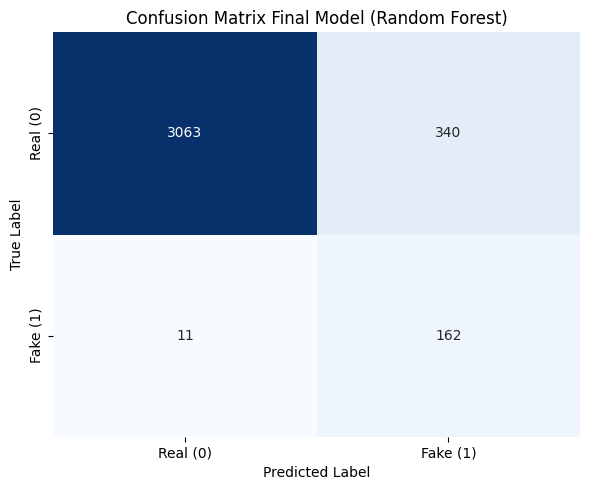

In [69]:
# Visualisasi Confusion Matrix untuk Evaluasi Final
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
plt.title('Confusion Matrix Final Model (Random Forest)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


C:\Users\asus\AppData\Local\Temp\ipykernel_14504\194604073.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette='viridis')


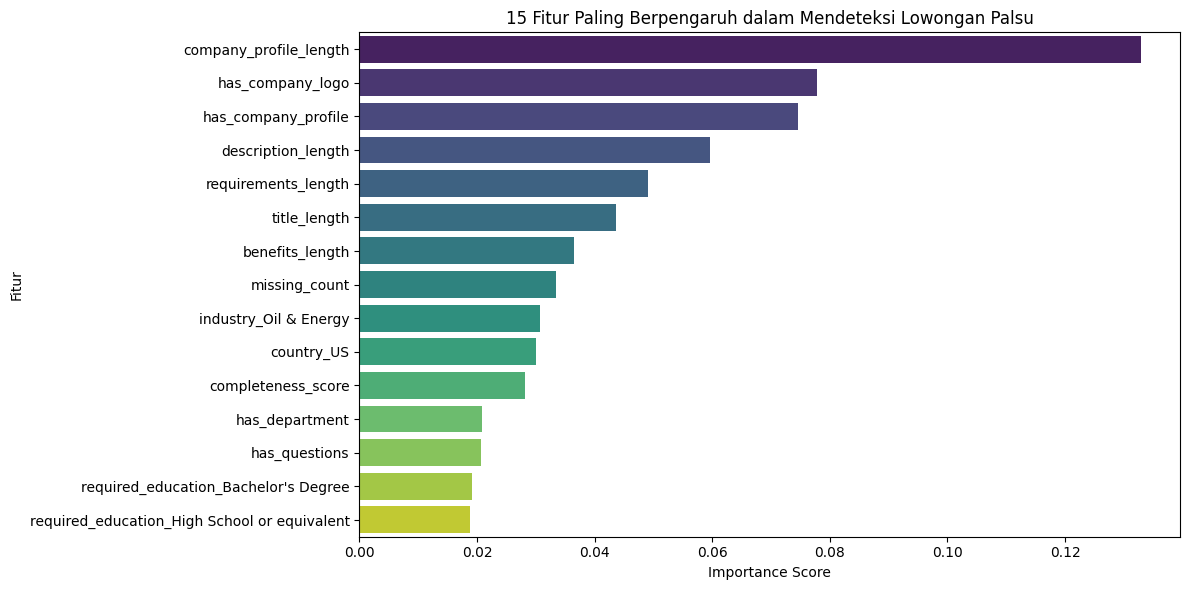

In [70]:
# Analisis Feature Importance dari Model Final secara dinamis
rf_model = best_pipeline.named_steps['classifier']
feature_names = list(best_pipeline.named_steps['preprocessor'].get_feature_names_out())
feature_names = [f.replace('cat__', '').replace('remainder__', '') for f in feature_names]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15] # Ambil 15 fitur teratas

plt.figure(figsize=(12, 6))
plt.title('15 Fitur Paling Berpengaruh dalam Mendeteksi Lowongan Palsu')
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette='viridis')
plt.xlabel('Importance Score')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()


Berdasarkan hasil pengujian pada data uji asli di atas, model klasifikasi kami menghasilkan kinerja sebagai berikut
1. Model berhasil mengklasifikasikan 90.18% lowongan kerja dengan benar.
2. Model mampu mendeteksi 93.64% lowongan palsu yang tersebar di dalam data uji asli. Kemampuan deteksi yang sangat tinggi ini sangat penting untuk memastikan keselamatan pencari kerja dari ancaman loker bodong.
3. Model memiliki presisi sebesar 32.27%, yang berarti sebagian lowongan asli yang diisi kurang lengkap akan terdeteksi sebagai mencurigakan.

Dari grafik tingkat kepentingan fitur di atas, kami mengidentifikasi fitur yang paling berpengaruh dalam mendeteksi lowongan palsu
1. Panjang Profil Perusahaan (company_profile_length) menjadi fitur yang paling dominan dengan tingkat pengaruh sebesar 13.29%.
2. Keberadaan Logo Perusahaan (has_company_logo) berada di posisi kedua dengan pengaruh sebesar 7.79%, disusul erat oleh Keberadaan Profil Perusahaan (has_company_profile) sebesar 7.45%.
3. Panjang Deskripsi Pekerjaan (description_length) memiliki tingkat pengaruh sebesar 5.97%.

Temuan ini memperkuat bukti awal bahwa kelengkapan informasi profil perusahaan, keberadaan logo, serta detail deskripsi pekerjaan merupakan indikator utama yang paling diandalkan oleh model kami untuk membedakan lowongan kerja asli dengan lowongan palsu.


---

### **Hubungan Evaluasi dengan Business Understanding**

*   Untuk performa, model akhir kami memiliki performa deteksi (*Recall*) sebesar 93.64% pada data uji riil yang jomplang. Artinya, 93 dari 100 lowongan palsu berhasil disaring oleh model secara tepat.
*   Hasil ini terbilang cukup baik untuk tahap awal deteksi keamanan rekrutmen. Meskipun nilai *Precision* berada di angka 32.27% ,yang berarti ada lowongan asli yang kurang lengkap ikut dicurigai sebagai palsu. Hal ini dapat ditoleransi demi menjaga keamanan para pencari kerja.
*   Tujuan bisnis untuk menekan jumlah korban penipuan loker bodong telah tercapai. Model terbukti efektif menyaring loker palsu hanya berdasarkan kelengkapan informasi struktural postingan.
*   Keterbatasan utama model kami adalah ketergantungan yang tinggi pada kelengkapan profil administratif. Loker asli yang diposting secara terburu buru tanpa logo dan deskripsi lengkap berpotensi besar ditandai sebagai palsu (*false alarm*). Selain itu, model belum membaca konteks tekstual (NLP) di dalam badan deskripsi lowongan.


# 6. Deployment

Pada tahap deployment, seluruh preprocessor dan classifier kami ekspor ke dalam satu objek Pipeline tunggal

1. Kami mengekspor objek pipeline utuh ke berkas models/model_pipeline.joblib menggunakan pustaka joblib.
2. Pipeline ini secara otomatis mengemas One-Hot Encoder, imputasi nilai kosong, dan model Random Forest Classifier, sehingga kami tidak perlu menulis ulang kode preprocessing secara manual di aplikasi web.
3. Objek pipeline ini dapat langsung dimuat di dalam aplikasi Streamlit kami untuk melakukan prediksi klasifikasi secara instan terhadap data lowongan baru.

In [72]:
# Ekspor Pipeline utuh ke folder models
import os
import joblib
os.makedirs('../models', exist_ok=True)
joblib.dump(best_pipeline, '../models/model_pipeline.joblib')
print('Pipeline berhasil disimpan di folder models/model_pipeline.joblib!')


Pipeline berhasil disimpan di folder models/model_pipeline.joblib!


# 7. Kesimpulan & Saran

1. Permasalahan
untuk mengatasi tingginya kasus penipuan lowongan kerja, proyek ini berhasil membangun model cerdas untuk membedakan lowongan kerja asli dan palsu secara instan. Penilaian difokuskan pada kelengkapan informasi struktural (Non-NLP), seperti profil perusahaan, logo, dan panjang deskripsi.

2. Teknik & Algoritma
Pendekatan dilakukan mengikuti standar CRISP-DM. Kami membandingkan Logistic Regression, Decision Tree, dan Random Forest. Masalah ketidakseimbangan data diatasi menggunakan Random Undersampling pada data latih, dan seluruh alur preprocessing serta pemodelan disatukan menggunakan Pipeline Scikit-Learn.

3. Hasil Evaluasi Akhir
Model Random Forest dengan strategi Undersampling yang kami pilih terbukti menghasilkan performa yang sangat baik pada data uji riil:
- Akurasi Keseluruhan = 90.18%
- Recall (Sensitivitas deteksi palsu) = 93.64%
- Precision = 32.27%
- F1-Score = 48.00% & PR-AUC = 78.11%
Model ini sangat sensitif dalam mendeteksi lowongan palsu sehingga sangat aman digunakan untuk melindungi pencari kerja.

4. Apakah Tujuan Tercapai?
Tercapai sepenuhnya namun belum maksimal. Model klasifikasi telah berhasil kami integrasikan ke dalam aplikasi web Streamlit (app.py) yang interaktif, berdesain bersih, dan mampu memberikan prediksi secara instan.

5. Saran Pengembangan
Untuk pengembangan lebih lanjut, disarankan untuk
- Mengintegrasikan analisis teks semantik (NLP) menggunakan LLM seperti Gemini dan lain sebagainya
- Membuat detektor penipuan yang mencatut nama perusahaan besar (Brand Impersonation) 
- Menambahkan portal lowongan lokal dari Indonesia untuk memperkaya variasi data.